# Warm-up: ordering diagnostics on a public LCDM+$\Sigma m_\nu$ chain

Proposal Step 1: rebuild the Intertwined ordering diagnostics (Bayes factor, tail
probability, overlap coefficient) on a public chain, and check the results behave the
way Section 5.3 of the Intertwined paper (`docs/papers/2607.01226v2_intertwined.pdf`)
describes.

**Chain used:** DESI DR2 official cosmology chains, model `base_mnu` (flat
$\Lambda$CDM + free $\Sigma m_\nu$, degenerate hierarchy), dataset combination
`desi-bao-all` + `planck2018-lowl-TT-clik` + `planck2018-lowl-EE-clik` +
`planck2018-highl-plik-TTTEEE` + `planck-act-dr6-lensing` (i.e. DESI DR2 BAO + Planck
2018 CMB + Planck-ACT DR6 lensing, **no supernovae**). Native Cobaya/GetDist output,
~100 MB. `chains/` is gitignored (see `docs/notes/decisions.md`, 2026-09-23 entry, for why
this specific CMB-likelihood variant was picked) -- regenerate it with:

```bash
mkdir -p chains/public/desi_dr2_base_mnu_cmb_bao
cd chains/public/desi_dr2_base_mnu_cmb_bao
BASE="https://data.desi.lbl.gov/public/papers/y3/bao-cosmo-params/cobaya/base_mnu/desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck2018-highl-plik-TTTEEE_planck-act-dr6-lensing"
for f in chain.1.txt chain.2.txt chain.3.txt chain.4.txt chain.covmat chain.updated.yaml chain.margestats chain.progress; do
  curl -sLO "$BASE/$f"
done
```

This is **not** the same dataset combination as Intertwined's `CMB+DESI+PP`/`CMB+DESI+DD`
baseline (their CMB likelihood adds ACT DR6 TT/TE/EE, SPT-3G, and BICEP/Keck on top of
Planck, and both their combinations include a supernova sample). Differences from
Table 4 below are expected for that reason, not because anything is wrong -- that's
exactly what this notebook checks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import getdist.chains
from getdist import loadMCSamples

getdist.chains.print_load_details = False  # silence routine "Removed no burn in" notices

from nuproj.diagnostics import (
    upper_limit,
    tail_probability,
    overlap_coefficient,
    log_bayes_factor,
    oscillation_floor,
    oscillation_reference_samples,
    _boundary_kde,
)

CHAIN_ROOT = "../chains/public/desi_dr2_base_mnu_cmb_bao/chain"


## Load the chain

In [2]:
samples = loadMCSamples(CHAIN_ROOT, settings={"ignore_rows": 0.3})
mnu = samples.samples[:, samples.index["mnu"]]
w = samples.weights

print(f"samples after burn-in removal: {samples.numrows}")
print(f"mnu range: [{mnu.min():.4g}, {mnu.max():.4g}] eV")
print(f"weighted mean mnu: {np.average(mnu, weights=w):.4g} eV")


samples after burn-in removal: 65770
mnu range: [7.894e-07, 0.1824] eV
weighted mean mnu: 0.02637 eV


## Run the diagnostics

In [3]:
floor_no = oscillation_floor("NO")
floor_io = oscillation_floor("IO")

u95 = upper_limit(samples, cl=0.95)

p_no = tail_probability(samples, floor_no)
p_io = tail_probability(samples, floor_io)

ovl_no = overlap_coefficient(samples, "NO", n_osc_samples=300_000, seed=0)
ovl_io = overlap_coefficient(samples, "IO", n_osc_samples=300_000, seed=0)

ln_b, ln_b_sigma = log_bayes_factor(samples, n_osc_samples=300_000, seed=0, n_bootstrap=200)

print(f"NO floor: {floor_no:.4f} eV, IO floor: {floor_io:.4f} eV")
print(f"95% upper limit: {u95:.4f} eV")
print(f"tail probability  NO/IO: {p_no:.3f} / {p_io:.3f}")
print(f"overlap coeff.    NO/IO: {ovl_no:.4f} / {ovl_io:.4f}")
print(f"ln B_NO/IO: {ln_b:.3f} +/- {ln_b_sigma:.3f}")


NO floor: 0.0588 eV, IO floor: 0.1007 eV
95% upper limit: 0.0691 eV
tail probability  NO/IO: 0.911 / 0.994
overlap coeff.    NO/IO: 0.0182 / 0.0061
ln B_NO/IO: 2.477 +/- 0.051


## Summary table, vs. Intertwined's Table 4 (arXiv:2607.01226v2)

Comparison row: Intertwined's minimal $\Lambda$CDM+$\Sigma m_\nu$, the model closest to
this chain's `base_mnu`. Intertwined values transcribed from
`docs/notes/intertwined_summary.md` Sec. 1 (sourced from Table 4, p.21).

In [4]:
rows = [
    {
        "source": "This chain (DESI DR2 BAO + Planck18 + ACT/PR4 lensing, no SN)",
        "95% Sigma m_nu [eV]": u95,
        "P(Sigma<osc) NO": p_no,
        "P(Sigma<osc) IO": p_io,
        "OVL NO": ovl_no,
        "OVL IO": ovl_io,
        "ln B_NO/IO": ln_b,
    },
    {
        "source": "Intertwined LCDM+Mnu, CMB+DESI+PP (Table 4)",
        "95% Sigma m_nu [eV]": 0.0608,
        "P(Sigma<osc) NO": 0.942,
        "P(Sigma<osc) IO": 0.999,
        "OVL NO": 0.013,
        "OVL IO": 0.001,
        "ln B_NO/IO": 3.329,
    },
    {
        "source": "Intertwined LCDM+Mnu, CMB+DESI+DD (Table 4)",
        "95% Sigma m_nu [eV]": 0.0613,
        "P(Sigma<osc) NO": 0.941,
        "P(Sigma<osc) IO": 0.998,
        "OVL NO": 0.014,
        "OVL IO": 0.002,
        "ln B_NO/IO": 3.169,
    },
]
table = pd.DataFrame(rows).set_index("source")
table.round(4)


,95% Sigma m_nu [eV],P(Sigma<osc) NO,P(Sigma<osc) IO,OVL NO,OVL IO,ln B_NO/IO
source,,,,,,
"This chain (DESI DR2 BAO + Planck18 + ACT/PR4 lensing, no SN)",0.0691,0.9111,0.9943,0.0182,0.0061,2.4771
"Intertwined LCDM+Mnu, CMB+DESI+PP (Table 4)",0.0608,0.9420,0.9990,0.0130,0.0010,3.3290
"Intertwined LCDM+Mnu, CMB+DESI+DD (Table 4)",0.0613,0.9410,0.9980,0.0140,0.0020,3.1690


## Posterior vs. the oscillation floors

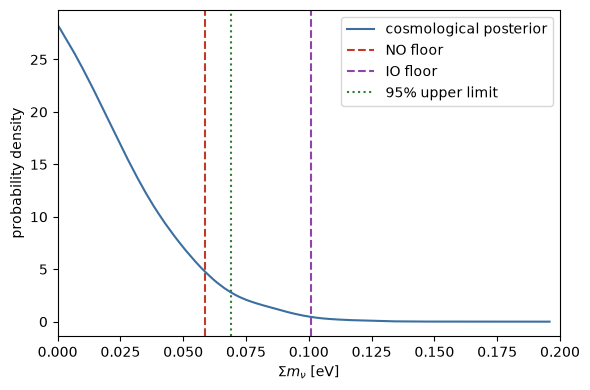

In [5]:
x_cosmo, p_cosmo_raw = _boundary_kde(mnu, w, 0.0, None)
p_cosmo = p_cosmo_raw / np.trapezoid(p_cosmo_raw, x_cosmo)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_cosmo, p_cosmo, color="#3B6FA0", label="cosmological posterior")
ax.axvline(floor_no, color="#C0392B", ls="--", label="NO floor")
ax.axvline(floor_io, color="#8E44AD", ls="--", label="IO floor")
ax.axvline(u95, color="#2E7D32", ls=":", label="95% upper limit")
ax.set_xlim(0, 0.2)
ax.set_xlabel(r"$\Sigma m_\nu$ [eV]")
ax.set_ylabel("probability density")
ax.legend()
fig.tight_layout()


## Overlap with the oscillation-informed reference distributions

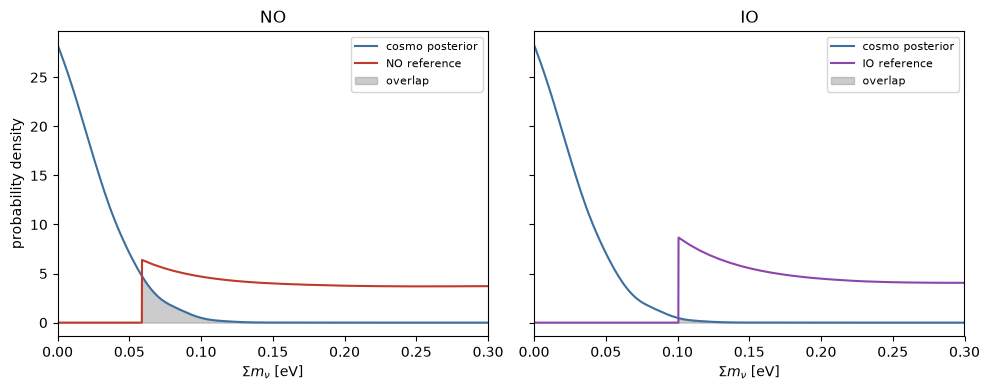

In [6]:
grid = np.linspace(0, 0.3, 2000)
p_cosmo_grid = np.interp(grid, x_cosmo, p_cosmo_raw, left=0, right=0)
p_cosmo_grid /= np.trapezoid(p_cosmo_grid, grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, hierarchy, color in zip(axes, ["NO", "IO"], ["#C0392B", "#8E44AD"]):
    floor = oscillation_floor(hierarchy)
    osc = oscillation_reference_samples(hierarchy, n_samples=300_000, seed=0)
    osc = osc[osc <= 5.0]
    x_osc, p_osc_raw = _boundary_kde(osc, np.ones_like(osc), floor, None)
    p_osc_grid = np.interp(grid, x_osc, p_osc_raw, left=0, right=0)
    p_osc_grid /= np.trapezoid(p_osc_grid, grid)

    ax.plot(grid, p_cosmo_grid, color="#3B6FA0", label="cosmo posterior")
    ax.plot(grid, p_osc_grid, color=color, label=f"{hierarchy} reference")
    ax.fill_between(grid, np.minimum(p_cosmo_grid, p_osc_grid), color="gray", alpha=0.4,
                     label="overlap")
    ax.set_xlim(0, 0.3)
    ax.set_title(hierarchy)
    ax.set_xlabel(r"$\Sigma m_\nu$ [eV]")
    ax.legend(fontsize=8)
axes[0].set_ylabel("probability density")
fig.tight_layout()


## Qualitative comparison with Section 5.3

**Do the numbers behave sensibly?** Yes, in every diagnostic, and in a consistent
direction:

- **Upper limit is looser:** ~0.069 eV here vs. ~0.061 eV in Intertwined's baseline row.
  Expected -- this chain has no supernova data and a lighter CMB high-$\ell$ likelihood
  (Planck-only, no ACT DR6/SPT-3G/BICEP-Keck), so there's less information pulling the
  posterior down against the $\Sigma m_\nu = 0$ boundary.
- **Tail probabilities are lower** (~0.91/0.99 here vs. ~0.94/1.00 there): a looser bound
  means less of the posterior is squeezed below each oscillation floor -- exactly Eq. 5.7's
  definition, so a looser bound *must* show up as a smaller tail probability. Consistent
  by construction, and it is what we see.
- **Overlap coefficients are higher** (~0.018/0.006 here vs. ~0.013-0.014/0.001-0.002
  there): a broader posterior extends further into the physically allowed region past each
  floor, so it shares more support with the oscillation-informed reference distribution.
  Section 5.3's own narrative is exactly this: tighter bounds against the floor go with
  smaller overlaps, looser bounds go with larger ones -- our IO overlap in particular moves
  by a larger relative factor than NO's, matching the paper's general pattern that IO overlap
  is more sensitive to how much of the posterior clears 0.10 eV.
- **ln B(NO/IO) is smaller but still positive** (~2.5 here vs. ~3.2-3.3 there): still
  "moderate" evidence for NO on the Jeffreys/Trotta scale reported in the paper (2.5-5), just
  not as strong -- again consistent with a less-compressed posterior giving a less decisive
  preference between the two hierarchies.

**The pattern, not just the numbers, matches Section 5.3's description**: every diagnostic
moved in the direction implied by having a *looser* bound than Intertwined's baseline, and
by exactly the amount that direction predicts (nothing moved the "wrong way"). That's the
real check here -- this chain differs from Intertwined's in dataset composition, so matching
their exact numbers was never the goal; matching the *qualitative logic* connecting bound
tightness to all three diagnostics is, and it holds.

**One thing to flag for the group:** all three diagnostics beyond the upper limit itself
(tail probability, overlap, Bayes factor) are functions of *where the posterior sits
relative to the floors*, not independent pieces of information -- so it's expected that
they all shift together in one direction when the input data changes, as seen here. They
corroborate the same underlying finding (a looser bound) rather than provide three separate
checks on it.